# 数据探查：新闻全文 (news)

路径：`/home/intern_fjq_2026/data/NLP/news/news_20240101_20241231.jsonl`

目标：彻底理解这份新闻类 jsonl 的整体数据结构。

> 前 3 个逻辑 cell：`read_json` 加载 `df` → `df.head()` → 打印 `shape` 与 `columns`。
> 注意：该文件只有 **标题 + 摘要**，完整正文经 `S3_URL` 指向的对象存储读取，不在本 jsonl 内。


In [1]:
import pandas as pd

df = pd.read_json('/home/intern_fjq_2026/data/NLP/news/news_20240101_20241231.jsonl', lines=True)


In [2]:
df.head()


,NEWS_ID,NEWS_TITLE,NEWS_PUBLISH_TIME,EFFECTIVE_TIME,NEWS_ORIGIN_SOURCE,NEWS_AUTHOR,NEWS_PUBLISH_SITE,NEWS_URL,S3_URL,NEWS_SUMMARY
0,192766375,农夫山泉新品官宣，矿泉水市场再迎洗牌,2024-01-01,2024-01-01,深响·林之柏,None,投融界,https://www.trjcn.com/news/detail_51562.html,/newsbody/DV8mAfAEZIphqzAhuoASYw,此次农夫山泉的矿泉水“上新”给冬季的瓶装水市场带来一股新风，在给消费者带来更多实惠的同时，我...
1,192240618,众钠能源完成近亿元A1轮融资，引领钠离子电池产业化新征程,2024-01-01,2024-01-01,投融界·若水,None,投融界,https://www.trjcn.com/news/detail_51534.html,/newsbody/ZADoKxLquTH05d0zt47_ug,专注于钠离子电池研发与制造的众钠能源宣布成功完成了由中合投资和黄海金控联手提供的近亿元A1轮...
2,190376683,天大钒业完成新一轮融资，投资方为国投创合,2024-01-01,2024-01-01,投融界,None,投融界,https://www.trjcn.com/news/detail_51443.html,/newsbody/_sdA33Aa8n_kUZaLPww1tg,钛合金用中间合金生产企业天大钒业完成新一轮融资，投资方为国投创合。天大钒业是一家长期专注于钛...
3,190208735,邦耀生物完成近2亿元B+轮融资，石药基金领投,2024-01-01,2024-01-01,投融界,None,投融界,https://www.trjcn.com/news/detail_51435.html,/newsbody/DJ13cOhXuu7S6ExRVMJnGQ,聚焦于基因和细胞治疗的上海邦耀生物科技有限公司宣布完成近2亿元人民币B+轮融资。邦耀生物是全...
4,190885783,黑五商家没爆单，“四小龙”对决亚马逊,2024-01-01,2024-01-01,时代财经APP·李馨婷,None,投融界,https://www.trjcn.com/news/detail_51467.html,/newsbody/SIUNHzILMqdhZCquR90Agg,2024年前三季度，我国跨境电商进出口达1.88万亿元，同比增长11.5%，其中出口1.48...


In [3]:
print("shape:", df.shape)
print("columns:")
print(df.columns.tolist())


shape: (23646143, 10)
columns:
['NEWS_ID', 'NEWS_TITLE', 'NEWS_PUBLISH_TIME', 'EFFECTIVE_TIME', 'NEWS_ORIGIN_SOURCE', 'NEWS_AUTHOR', 'NEWS_PUBLISH_SITE', 'NEWS_URL', 'S3_URL', 'NEWS_SUMMARY']


In [4]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["font.sans-serif"] = ["WenQuanYi Micro Hei", "WenQuanYi Zen Hei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("DataFrame shape:", df.shape)
print("内存占用(deep): {:.1f} MB".format(df.memory_usage(deep=True).sum() / 1024**2))
time_cols = ["NEWS_PUBLISH_TIME", "EFFECTIVE_TIME"]
text_cols = ["NEWS_TITLE", "NEWS_SUMMARY"]
cat_cols  = ["NEWS_ORIGIN_SOURCE", "NEWS_AUTHOR", "NEWS_PUBLISH_SITE"]
url_cols  = ["NEWS_URL", "S3_URL"]
id_cols   = ["NEWS_ID"]

field_meaning = {
    "NEWS_ID": "新闻唯一ID",
    "NEWS_TITLE": "新闻标题",
    "NEWS_PUBLISH_TIME": "发布时间",
    "EFFECTIVE_TIME": "生效/抓取时间",
    "NEWS_ORIGIN_SOURCE": "原始来源媒体",
    "NEWS_AUTHOR": "作者",
    "NEWS_PUBLISH_SITE": "发布站点",
    "NEWS_URL": "原文链接",
    "S3_URL": "正文存储路径(S3 key)",
    "NEWS_SUMMARY": "新闻摘要",
}
pd.DataFrame({"字段含义": field_meaning}).reindex(df.columns)


DataFrame shape: (23646143, 10)


内存占用(deep): 18664.3 MB


,字段含义
NEWS_ID,新闻唯一ID
NEWS_TITLE,新闻标题
NEWS_PUBLISH_TIME,发布时间
EFFECTIVE_TIME,生效/抓取时间
NEWS_ORIGIN_SOURCE,原始来源媒体
NEWS_AUTHOR,作者
NEWS_PUBLISH_SITE,发布站点
NEWS_URL,原文链接
S3_URL,正文存储路径(S3 key)
NEWS_SUMMARY,新闻摘要


## 1. 字段类型 / 缺失 / 唯一值总览


In [5]:
# ============================================================
# 1. 字段类型 / 缺失 / 唯一值总览
# ============================================================
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "null": df.isna().sum(),
    "null_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=False),
})
overview.sort_values(["null_pct", "n_unique"], ascending=[False, False])


,dtype,non_null,null,null_pct,n_unique
NEWS_AUTHOR,object,2748029,20898114,88.38,62947
NEWS_ORIGIN_SOURCE,object,21339788,2306355,9.75,76657
NEWS_SUMMARY,object,23632504,13639,0.06,17082494
NEWS_ID,int64,23646143,0,0.00,23646143
NEWS_URL,object,23646143,0,0.00,23646143
S3_URL,object,23646041,102,0.00,23646042
NEWS_TITLE,object,23646143,0,0.00,17252489
NEWS_PUBLISH_TIME,datetime64[ns],23646143,0,0.00,7808211
EFFECTIVE_TIME,datetime64[ns],23646143,0,0.00,6223624
NEWS_PUBLISH_SITE,object,23646143,0,0.00,831


## 2. 主键 / 唯一性 / 重复


In [6]:
# ============================================================
# 2. 主键 / 唯一性 / 重复
# ============================================================
print("总行数:", len(df))
print("NEWS_ID 唯一性 is_unique =", df["NEWS_ID"].is_unique, "| 唯一值数 =", df["NEWS_ID"].nunique())
print("完全重复的行数 =", int(df.duplicated().sum()))
print("去掉 NEWS_ID 后仍完全重复的记录数 =", int(df.drop(columns=["NEWS_ID"]).duplicated().sum()))
print("S3_URL 非空 = %d，唯一值 = %d，重复(正文指针复用) = %d" % (
    int(df["S3_URL"].notna().sum()), df["S3_URL"].nunique(),
    int(df["S3_URL"].dropna().duplicated().sum())))


总行数: 23646143


NEWS_ID 唯一性 is_unique = True | 唯一值数 = 23646143


完全重复的行数 = 0


去掉 NEWS_ID 后仍完全重复的记录数 = 0


S3_URL 非空 = 23646041，唯一值 = 23646041，重复(正文指针复用) = 0


## 3. 时间维度


NEWS_PUBLISH_TIME 解析失败行数: 0
发布时间范围: 2023-12-31 14:48:00 → 2025-08-07 15:31:06


发布时间去重日期数: 376

按月发布量：
2023-12        200
2024-01    1986946
2024-02    1467211
2024-03    1914704
2024-04    1940878
2024-05    1568281
2024-06    1935327
2024-07    2231867
2024-08    2328587
2024-09    2107202
2024-10    1978667
2024-11    2039672
2024-12    2146592
2025-01          1
2025-02          1
2025-03          1
2025-04          1
2025-06          2
2025-07          1
2025-08          2
Freq: M, Name: NEWS_PUBLISH_TIME, dtype: int64



生效时间 - 发布时间 时差(分钟): min/中位/均值/max = -666694.3 / 8.7 / 41.4 / 1440.0


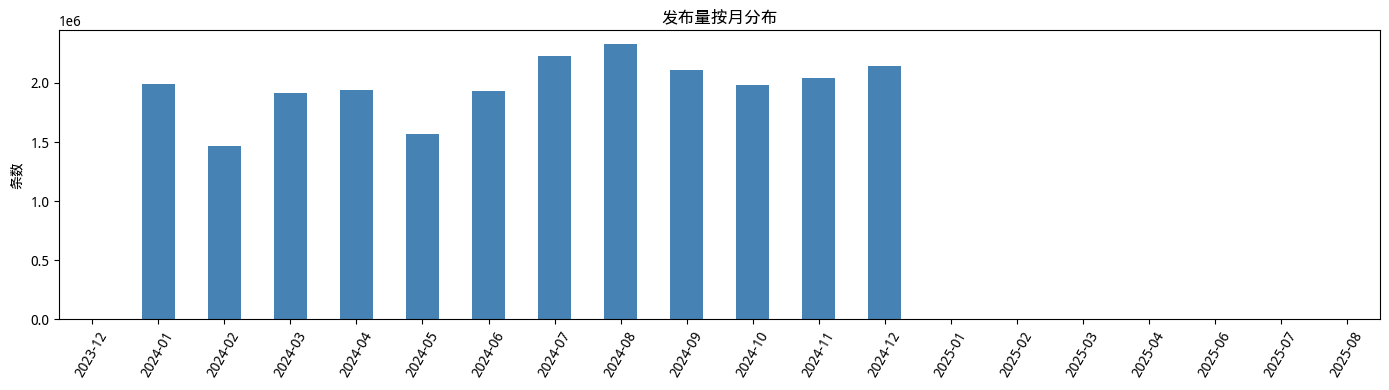

In [7]:
# ============================================================
# 3. 时间维度
# ============================================================
pub = pd.to_datetime(df["NEWS_PUBLISH_TIME"], errors="coerce")
eff = pd.to_datetime(df["EFFECTIVE_TIME"], errors="coerce")
print("NEWS_PUBLISH_TIME 解析失败行数:", int(pub.isna().sum()))
print("发布时间范围:", pub.min(), "→", pub.max())
print("发布时间去重日期数:", pub.dt.normalize().nunique())

monthly = pub.dt.to_period("M").value_counts().sort_index()
print("\n按月发布量：")
print(monthly)

lag_min = (eff - pub).dt.total_seconds() / 60
print("\n生效时间 - 发布时间 时差(分钟): min/中位/均值/max = %.1f / %.1f / %.1f / %.1f" % (
    lag_min.min(), lag_min.median(), lag_min.mean(), lag_min.max()))

plt.figure(figsize=(14, 4))
monthly.plot(kind="bar", color="steelblue")
plt.title("发布量按月分布")
plt.ylabel("条数")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


## 4. 文本字段（TITLE / SUMMARY）


NEWS_TITLE 无缺失 = True | 长度 min/中位/均值/max = 3 / 29.0 / 29.2 / 285



NEWS_SUMMARY 非空 23632504 / 23646143，缺失 13639 (0.06%)


NEWS_SUMMARY(非空) 长度：min/中位/均值/max = 1 / 87.0 / 83.8 / 1000
SUMMARY 长度分位数：


0.00       1.0
0.25      66.0
0.50      87.0
0.75     104.0
0.90     114.0
0.99     120.0
1.00    1000.0
Name: NEWS_SUMMARY, dtype: float64



标题去重: TITLE 唯一值 17252489 / 行数 23646143，重复标题行数 = 6393654


摘要去重: SUMMARY 唯一值(非空) 17082493 / 非空 23632504，重复摘要条数 = 6550011


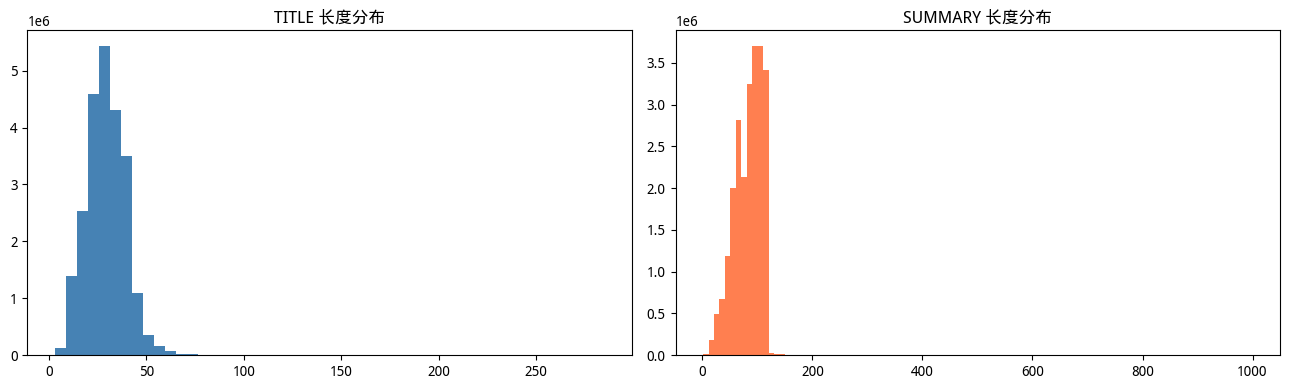


--- 最长摘要样本 ---
index=22021007, 长度=1000, 标题=跨年行情启动了？微盘股到头没？
本周上证指数涨2.33%，沪深300涨1.44%，日均交易额17246亿，环比上周有所上升。面向12月是否演绎跨年行情，市场高度期待后续中央经济会议能够形成政策面进一步利好预期。站在当前，要明确924行情以来市场起伏波动主要是因为情绪。跨年行情倒值得期待的前提条件在于11月M1增速持续提升得到验证，形成连续两个月以上的M1增速回升是关键的。若要以“创10月8日大盘新高”看待这波或有的“跨年行情”，我们认为必须要满足两个条件：1、美元指数明确由强转弱；2、财政支出进入到明确扩张周期。对于前者，对于市场敏锐者已感受到国内货币政策战略宽松周期已开启，这在近期十年期国债收益率破2%后的官方态度上可见一斑；同时，对于A股资金入场闸门，监管层明确欢迎“短期投资、长期投资”并承诺打通“长期资金入市的堵点”，不难看出基于“流动性”视角推动股市向上的战略要素已完备，而短期基于流动性使得市场突破震荡格局，其技术性疑点在强弱美元问题。在特朗普上台早期强美元状态下，人民币贬值压力依然会形成压制，我们要等待的是美元由强转弱的契机。对于后者，需要明确的是：当前财政政策的核心目的看得出是以缓解地方财政困境为首要，要本质上实现“房地产止跌回稳”抑或“扭转通缩预期”这种重大转折或许在明年二季度后期才能够看得清晰准确。目前看，所谓“跨年行情”虽值得期待，但本质上还是基于震荡市思维，是此前跌出来的空间，跨年有没有行情看M1，跨年是不是大行情看美元由强转弱。结构上，最引入瞩目的问题是微盘股指数持续创出新高，相对沪深300指数走势也创出历史新高。从微盘股指数诞生以来，增量资金核心是散户游资，与两融资金高度相关，只要市场成交量能够维持在1.5万亿以上则提供其存在的土壤。这种大小盘极致的分化：一方面值得注意是随着12月上旬两大重要会议临近，融资资金交易热度回落或出现在会议落地后的政策真空期，那么对应环境下高股息策略在十年期国债利率走低下会占优，可以看到924行情以来“价值派抱团”并未瓦解，近期正在加速高股息配置。另一方面，基于大小盘分化视角，关键是11月M1能否释放出连续改善的信号。回顾历史看，在M1自底部出现连续两个月回升后消费和顺周期板块为代表大盘领域就会展开定价。两股潜在力量都使得这种大

In [8]:
# ============================================================
# 4. 文本字段长度 / 重复 / 样本
# ============================================================
title_len = df["NEWS_TITLE"].str.len()
print("NEWS_TITLE 无缺失 =", bool(df["NEWS_TITLE"].notna().all()),
      "| 长度 min/中位/均值/max = %d / %.1f / %.1f / %d" % (
          title_len.min(), title_len.median(), title_len.mean(), title_len.max()))

summary = df["NEWS_SUMMARY"].dropna()
print("\nNEWS_SUMMARY 非空 %d / %d，缺失 %d (%.2f%%)" % (
    len(summary), len(df),
    int(df["NEWS_SUMMARY"].isna().sum()), df["NEWS_SUMMARY"].isna().mean() * 100))
slen = summary.str.len()
print("NEWS_SUMMARY(非空) 长度：min/中位/均值/max = %d / %.1f / %.1f / %d" % (
    slen.min(), slen.median(), slen.mean(), slen.max()))
print("SUMMARY 长度分位数：")
print(slen.quantile([0.0, 0.25, 0.5, 0.75, 0.9, 0.99, 1.0]))

print("\n标题去重: TITLE 唯一值 %d / 行数 %d，重复标题行数 = %d" % (
    df["NEWS_TITLE"].nunique(), len(df), int(df["NEWS_TITLE"].duplicated().sum())))
print("摘要去重: SUMMARY 唯一值(非空) %d / 非空 %d，重复摘要条数 = %d" % (
    summary.nunique(), len(summary), int(summary.duplicated().sum())))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(title_len, bins=50, color="steelblue")
axes[0].set_title("TITLE 长度分布")
axes[1].hist(slen, bins=100, color="coral")
axes[1].set_title("SUMMARY 长度分布")
plt.tight_layout()
plt.show()

print("\n--- 最长摘要样本 ---")
i = slen.idxmax()
print("index=%d, 长度=%d, 标题=%s" % (i, slen[i], df.loc[i, "NEWS_TITLE"]))
print(df.loc[i, "NEWS_SUMMARY"][:1500])
print("\n--- 最短摘要样本 ---")
j = slen.idxmin()
print("index=%d, 长度=%d, 标题=%s" % (j, slen[j], df.loc[j, "NEWS_TITLE"]))
print(repr(df.loc[j, "NEWS_SUMMARY"]))


## 5. 分类字段（来源媒体 / 作者 / 站点）


NEWS_ORIGIN_SOURCE  唯一值数=76656


None            2306355
东方财富Choice数据    1492581
同花顺iNews        1256837
新浪证券-红岸工作室       944672
自选股写手            833543
证券之星股票           688342
每日经济新闻           637655
金融界              558386
证星主力研究           477145
证券之星资金流向         449494
证星基金日报           445340
证券之星             403995
自选股智能写手          400525
证券时报网            364464
界面新闻             298686
财联社              283748
智通财经             264075
来源： 金融界          249767
智选洞察             234679
证星融资融券           205288



NEWS_AUTHOR  唯一值数=62946


None      20898114
财智星         929698
金融界         122566
证券之星        109204
行情君          53960
每日经济新闻       29698
数据宝          26212
天眼君          21341
证券时报         21304
和讯网          18968
债券君          18667
情报员          12595
新浪财经         12000
张甡喆          11843
admin        11470
界面有连云        11232
公告君          10555
转融通           9976
杨跃滂           9870
理财君           9856



NEWS_PUBLISH_SITE  唯一值数=831
证券之星      5203539
新浪财经      3372101
东方财富网     3029094
同花顺       2363990
腾讯网       1466734
和讯网       1359232
搜狐财经       622188
同花顺个股      504978
财联社        360702
金融界        360617
网易财经       330884
智通财经网      168424
中金在线       165336
格隆汇        159527
人民网        102841
网易科技        91293
观点地产网       80434
上观          79922
海外网         79888
同花顺app      70371



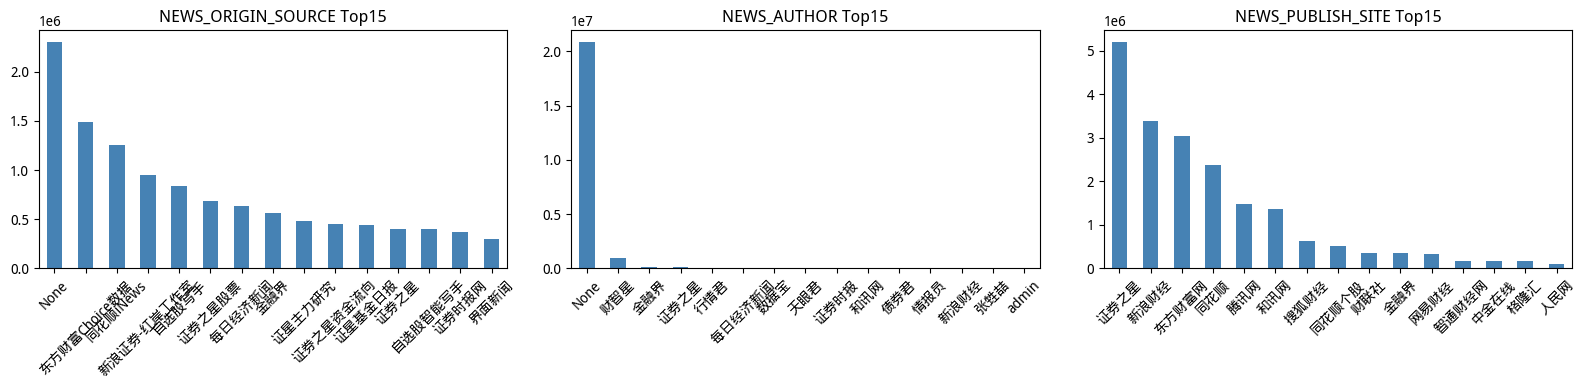

In [9]:
# ============================================================
# 5. 分类字段取值分布
# ============================================================
for c in cat_cols:
    print("=" * 70)
    print("%s  唯一值数=%d" % (c, df[c].nunique(dropna=True)))
    print(df[c].value_counts(dropna=False).head(20).to_string())
    print()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, c in enumerate(cat_cols):
    df[c].value_counts(dropna=False).head(15).plot(kind="bar", ax=axes[i], color="steelblue")
    axes[i].set_title(c + " Top15")
    axes[i].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## 6. 链接与正文存储指针


In [10]:
# ============================================================
# 6. 链接与正文存储指针
# ============================================================
dom = df["NEWS_URL"].dropna().str.extract(r"https?://([^/]+)", expand=False)
print("NEWS_URL 域名 Top20：")
print(dom.value_counts().head(20).to_string())

print("\nS3_URL 前缀样例(前 10)：")
for s in df["S3_URL"].dropna().unique()[:10]:
    print("  ", s)
print("S3_URL 去重唯一值 =", df["S3_URL"].nunique(),
      "| 复用 (重复) 的指针数 =", int(df["S3_URL"].dropna().duplicated().sum()))


NEWS_URL 域名 Top20：
stock.stockstar.com          4269185
finance.sina.com.cn          3038331
finance.eastmoney.com        3012905
gu.qq.com                    1325981
stock.10jqka.com.cn          1155221
stock.hexun.com               827633
www.sohu.com                  622188
yuanchuang.10jqka.com.cn      590418
www.163.com                   422177
finance.stockstar.com         377967
news.10jqka.com.cn            373826
t.10jqka.com.cn               364532
www.cls.cn                    360702
fund.stockstar.com            321138
stock.jrj.com.cn              187461
stock.finance.sina.com.cn     169077
www.zhitongcaijing.com        168424
futures.stockstar.com         163691
www.gelonghui.com             159527
field.10jqka.com.cn           158394

S3_URL 前缀样例(前 10)：


   /newsbody/DV8mAfAEZIphqzAhuoASYw
   /newsbody/ZADoKxLquTH05d0zt47_ug
   /newsbody/_sdA33Aa8n_kUZaLPww1tg
   /newsbody/DJ13cOhXuu7S6ExRVMJnGQ
   /newsbody/SIUNHzILMqdhZCquR90Agg
   /newsbody/ToI_Q3CWk0NN86-pFjWZ2g
   /newsbody/jLLGq2OGt9pGc9ikaBslJA
   /newsbody/xz1CGRHyPWeJBGEbuWzfgw
   /newsbody/rPsrimwsXLAHCrq_PKSsxw
   /newsbody/Ild3bJFMnGb_-Aji3V8qfw


S3_URL 去重唯一值 = 23646041 | 复用 (重复) 的指针数 = 0


## 7. 来源媒体 ↔ 站点 / 作者 关系


In [11]:
# ============================================================
# 7. 来源媒体 ↔ 站点 / 作者 关系
# ============================================================
src_sites = df.groupby("NEWS_ORIGIN_SOURCE")["NEWS_PUBLISH_SITE"].nunique().sort_values(ascending=False)
print("每个来源媒体对应发布站点数 Top20：")
print(src_sites.head(20).to_string())

site_authors = df.groupby("NEWS_PUBLISH_SITE")["NEWS_AUTHOR"].nunique().sort_values(ascending=False)
print("\n每个站点作者数 Top20：")
print(site_authors.head(20).to_string())


每个来源媒体对应发布站点数 Top20：
NEWS_ORIGIN_SOURCE
新华社        323
人民日报       255
新华网        232
人民网        200
经济日报       186
中国政府网      183
央视新闻       181
中国新闻网      174
央视网        162
央视新闻客户端    159
央广网        147
光明日报       140
经济参考报      139
科技日报       123
人民日报海外版    122
澎湃新闻       116
证券日报       115
央视财经       115
北京日报       111
中国经济网      109



每个站点作者数 Top20：
NEWS_PUBLISH_SITE
东方财富网      13048
澎湃         12266
搜狐财经       11821
新浪财经       10724
上观          7097
投资界         2118
虎嗅          1799
36氪         1076
证券之星        1035
汽车头条         832
艾肯家电网        799
家电网          784
同花顺app       753
全景网          540
证券市场红周刊      388
techweb      354
云掌财经         287
华夏时报         218
国际金融报网       184
经济观察网        182


## 8. 原始数据抽样查看


In [12]:
# ============================================================
# 8. 原始数据抽样查看
# ============================================================
sample = df.sample(n=3, random_state=42)
for i, (idx, row) in enumerate(sample.iterrows(), 1):
    print("=" * 80)
    print("样本 %d / 3   (原始 index=%d, NEWS_ID=%s)" % (i, idx, row["NEWS_ID"]))
    print("-" * 80)
    for col in df.columns:
        val = row[col]
        if isinstance(val, str) and len(val) > 300:
            val = val[:300] + "  ......[截断]"
        print("%-22s : %s" % (col, val))
    print()


样本 1 / 3   (原始 index=9264404, NEWS_ID=173657247)
--------------------------------------------------------------------------------
NEWS_ID                : 173657247
NEWS_TITLE             : 人工智能、探月出现在高考作文中！2024年普通高考语文作文试题来了
NEWS_PUBLISH_TIME      : 2024-06-07 11:48:50
EFFECTIVE_TIME         : 2024-06-07 11:49:29
NEWS_ORIGIN_SOURCE     : 中国青年报客户端
NEWS_AUTHOR            : None
NEWS_PUBLISH_SITE      : 中青在线
NEWS_URL               : http://news.cyol.com/gb/articles/2024-06/07/content_Q4LxAmujPW.html
S3_URL                 : /newsbody/Qdp0As-3to0Rmuza-ZCsaQ
NEWS_SUMMARY           : 2024年高考语文作文试题共6套。新课标II卷的作文中出现了“嫦娥四号”探月任务、“天问一号”等内容。请以“月的独白”为题目，用月亮的口吻，写一首小诗或一段抒情文字。

样本 2 / 3   (原始 index=667354, NEWS_ID=161424437)
--------------------------------------------------------------------------------
NEWS_ID                : 161424437
NEWS_TITLE             : *ST凯撒：凯撒旅游目前推出“全系列”邮轮产品 涉及母港、海外及极地环球航线
NEWS_PUBLISH_TIME      : 2024-01-11 15:12:00
EFFECTIVE_TIME         : 2024-01-11 16:11:48
NEWS_ORIGIN_S

## 9. 结论摘要（自动汇总）


In [13]:
# ============================================================
# 9. 结论摘要（自动汇总）
# ============================================================
pub_dt = pd.to_datetime(df["NEWS_PUBLISH_TIME"], errors="coerce")
lines = []
lines.append("文件: /home/intern_fjq_2026/data/NLP/news/news_20240101_20241231.jsonl")
lines.append("总记录数: %d 行 × %d 列" % df.shape)
lines.append("发布时间范围: %s ~ %s (去重日期 %d 天)" % (
    pub_dt.min(), pub_dt.max(), pub_dt.dt.normalize().nunique()))
lines.append("NEWS_ID 唯一: %s；完全重复行: %d；去掉 ID 后重复: %d" % (
    df["NEWS_ID"].is_unique, int(df.duplicated().sum()),
    int(df.drop(columns=["NEWS_ID"]).duplicated().sum())))
lines.append("发布站点 %d 个 / 来源媒体 %d 个 / 作者 %d 个" % (
    df["NEWS_PUBLISH_SITE"].nunique(), df["NEWS_ORIGIN_SOURCE"].nunique(),
    df["NEWS_AUTHOR"].nunique()))
lines.append("摘要(NEWS_SUMMARY)缺失率: %.2f%%；标题缺失率: %.2f%%；标题重复数: %d" % (
    df["NEWS_SUMMARY"].isna().mean()*100, df["NEWS_TITLE"].isna().mean()*100,
    int(df["NEWS_TITLE"].duplicated().sum())))
lines.append("S3_URL(正文指针) 非空 %d，唯一 %d，复用 %d" % (
    int(df["S3_URL"].notna().sum()), df["S3_URL"].nunique(),
    int(df["S3_URL"].dropna().duplicated().sum())))
print("\n".join(lines))


文件: /home/intern_fjq_2026/data/NLP/news/news_20240101_20241231.jsonl
总记录数: 23646143 行 × 10 列
发布时间范围: 2023-12-31 14:48:00 ~ 2025-08-07 15:31:06 (去重日期 376 天)
NEWS_ID 唯一: True；完全重复行: 0；去掉 ID 后重复: 0
发布站点 831 个 / 来源媒体 76656 个 / 作者 62946 个
摘要(NEWS_SUMMARY)缺失率: 0.06%；标题缺失率: 0.00%；标题重复数: 6393654
S3_URL(正文指针) 非空 23646041，唯一 23646041，复用 0
